## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Load the Wine Dataset

In [2]:
wine = load_wine(as_frame=True)
df = wine.frame.copy()
df = df.rename(columns={'target': 'class'})
df['class'] = df['class'].map({0: 'class_0', 1: 'class_1', 2: 'class_2'})
print("\nFirst 5 rows of the dataset:")
print(df.head())


First 5 rows of the dataset:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines 

## Quick Exploration

In [3]:
print("\nDataset shape:", df.shape)
print("Classes:", df['class'].unique())
print("\nBasic statistics:")
print(df.describe().round(2))


Dataset shape: (178, 14)
Classes: ['class_0' 'class_1' 'class_2']

Basic statistics:
       alcohol  malic_acid     ash  alcalinity_of_ash  magnesium  \
count   178.00      178.00  178.00             178.00     178.00   
mean     13.00        2.34    2.37              19.49      99.74   
std       0.81        1.12    0.27               3.34      14.28   
min      11.03        0.74    1.36              10.60      70.00   
25%      12.36        1.60    2.21              17.20      88.00   
50%      13.05        1.87    2.36              19.50      98.00   
75%      13.68        3.08    2.56              21.50     107.00   
max      14.83        5.80    3.23              30.00     162.00   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count         178.00      178.00                178.00           178.00   
mean            2.30        2.03                  0.36             1.59   
std             0.63        1.00                  0.12             0.57   
m

## Select Features

In [4]:
features = ['alcohol', 'color_intensity']
X = df[features]
y = df['class']

print("\nSelected features for visualization:")
print(X.head())


Selected features for visualization:
   alcohol  color_intensity
0    14.23             5.64
1    13.20             4.38
2    13.16             5.68
3    14.37             7.80
4    13.24             4.32


## Train-Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("\nTraining samples :", X_train.shape[0])
print("Testing samples  :", X_test.shape[0])


Training samples : 124
Testing samples  : 54


## Create and Train Naive Bayes Model

In [6]:
model = GaussianNB()
model.fit(X_train, y_train)

print("\nGaussian Naive Bayes model trained!")


Gaussian Naive Bayes model trained!


## Make Predictions

In [7]:
y_pred = model.predict(X_test)

print("\nFirst 10 predictions vs actual:")
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})
print(comparison.head(10))


First 10 predictions vs actual:
    Actual Predicted
0  class_0   class_0
1  class_1   class_1
2  class_0   class_2
3  class_0   class_0
4  class_0   class_1
5  class_0   class_0
6  class_2   class_2
7  class_1   class_1
8  class_1   class_2
9  class_2   class_1


## Evaluate the Model

In [8]:
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}  ({accuracy*100:.2f}%)")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.7593  (75.93%)

Confusion Matrix:
[[14  2  2]
 [ 3 17  1]
 [ 4  1 10]]

Classification Report:
              precision    recall  f1-score   support

     class_0       0.67      0.78      0.72        18
     class_1       0.85      0.81      0.83        21
     class_2       0.77      0.67      0.71        15

    accuracy                           0.76        54
   macro avg       0.76      0.75      0.75        54
weighted avg       0.77      0.76      0.76        54



## Visualize Decision Boundary

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


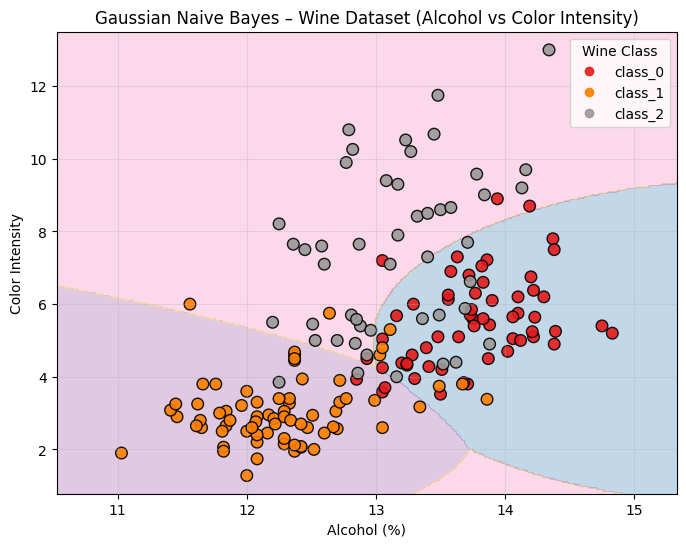


--- End of Naive Bayes Example with Wine Dataset ---


In [10]:
def plot_decision_boundary(model, X, y, title="Naive Bayes Decision Boundary"):
    x_min, x_max = X.iloc[:, 0].min() - 0.5, X.iloc[:, 0].max() + 0.5
    y_min, y_max = X.iloc[:, 1].min() - 0.5, X.iloc[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])

    # Define the mapping from class labels to integers
    class_mapping = {'class_0': 0, 'class_1': 1, 'class_2': 2}

    # Convert string labels in Z to numerical values
    Z_numeric = np.array([class_mapping[label] for label in Z])
    Z = Z_numeric.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, levels=3, cmap='Set1')

    # Scatter plot of points colored by true class using the same mapping
    scatter = plt.scatter(
        X.iloc[:, 0], X.iloc[:, 1],
        c=y.map(class_mapping),
        edgecolor='k', cmap='Set1', s=70, alpha=0.9
    )

    plt.xlabel('Alcohol (%)')
    plt.ylabel('Color Intensity')
    plt.title(title)
    plt.legend(handles=scatter.legend_elements()[0],
               labels=['class_0', 'class_1', 'class_2'],
               title="Wine Class")
    plt.grid(alpha=0.3)
    plt.show()

plot_decision_boundary(model, X, y, "Gaussian Naive Bayes – Wine Dataset (Alcohol vs Color Intensity)")

print("\n--- End of Naive Bayes Example with Wine Dataset ---")

## Conclusion

In this assignment, we implemented a **Gaussian Naive Bayes classifier** on the Wine dataset using only two features (Alcohol and Color Intensity) for clear visualization. Despite its strong assumption of feature independence, the model achieved good classification performance by effectively capturing the probabilistic relationships between the selected features and wine classes. The decision boundary plot clearly shows how Naive Bayes separates the three wine cultivars in the feature space. Overall, this demonstrates that Naive Bayes is a simple, fast, and surprisingly effective classifier for problems with continuous features — especially when computational efficiency and interpretability are important.